# Evaluierung des DPO-Übersetzungsmodells auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert das mit **Direct Preference Optimization (DPO)** trainierte Übersetzungsmodell auf dem unabhängigen **Lebenshilfe-Testdatensatz**:
1. **DPO-Modell laden:** Lädt die trainierten LoRA-Adapter aus dem DPO-Modellordner (`results/models/dpo_trained_model`) und hängt sie an das SFT-Basismodell (`results/models/new_pipeline/sft`).
2. **Reward- & Metrik-Setup:**
   - **Stil & Einfachheit ($R_{\text{style}}$):** BiLSTM Synthetic Regressor.
   - **Semantische Ähnlichkeit ($R_{\text{sem}}$):** Sentence-BERT Ähnlichkeit zur AS-Quelle.
   - **Referenz-Treue:** SBERT Ähnlichkeit zur echten menschlichen LS-Referenz.
   - **Composite Reward:** Kombinierter Qualitäts-Score.
3. **Batch-Übersetzung** aller Artikel des Lebenshilfe-Datensatzes (ohne Prompt-Prefix).
4. **Quantitative & Statistische Auswertung** (inkl. direktem Vergleich zu SFT falls vorhanden).
5. **Qualitatives Stichproben-Audit** & Interaktive Übersetzung.

In [1]:
import os
import sys
import json
import glob
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PFADE
# ==============================================================================
SFT_MODEL_PATH = "results/models/sft"
DPO_MODEL_PATH = "results/models/dpo_mixup"
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"
REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json"

SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

W_STYLE = 0.5
W_SEM = 0.5
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
PROMPT_PREFIX = ""

print(f"SFT Modell-Pfad:       {SFT_MODEL_PATH}")
print(f"DPO Modell-Pfad:       {DPO_MODEL_PATH}")
print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH}")
print(f"Reward Modell:         {REWARD_MODEL_PATH}")
print(f"Reward Vokabular:      {REWARD_VOCAB_PATH}")


SFT Modell-Pfad:       results/models/sft
DPO Modell-Pfad:       results/models/dpo_mixup
Lebenshilfe-Datensatz: data/lebenshilfe/lebenshilfe_dataset_clean.json
Reward Modell:         results/models/bilstm_mixup_regression.pt
Reward Vokabular:      data/vocabs/mixup_vocab.json


## 1. DPO-Modell & Tokenizer aus Ordner laden

In [3]:
print("Lade Tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(DPO_MODEL_PATH, use_fast=False)
except Exception:
    try:
        tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, use_fast=False)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50", use_fast=False)

tokenizer.src_lang = "de_DE"
tokenizer.tgt_lang = "de_DE"

print("--- 1. SFT-Basismodell laden ---")
print(f"SFT-Pfad: {SFT_MODEL_PATH}")
is_sft_lora = os.path.isdir(SFT_MODEL_PATH) and os.path.exists(os.path.join(SFT_MODEL_PATH, "adapter_config.json"))
has_full_weights = os.path.isdir(SFT_MODEL_PATH) and (
    os.path.exists(os.path.join(SFT_MODEL_PATH, "model.safetensors")) or 
    os.path.exists(os.path.join(SFT_MODEL_PATH, "pytorch_model.bin"))
) and os.path.exists(os.path.join(SFT_MODEL_PATH, "config.json"))

pt_file = None
if os.path.isfile(SFT_MODEL_PATH) and SFT_MODEL_PATH.endswith((".pt", ".pth", ".bin")):
    pt_file = SFT_MODEL_PATH
elif os.path.isdir(SFT_MODEL_PATH):
    for cand in ["sft.pt", "pytorch_model.bin", "model.pt"]:
        cand_p = os.path.join(SFT_MODEL_PATH, cand)
        if os.path.exists(cand_p):
            pt_file = cand_p
            break

if is_sft_lora:
    print("LoRA Adapter-Verzeichnis für SFT erkannt. Lade Basismodell und verschmelze Adapter (merge_and_unload)...")
    try:
        with open(os.path.join(SFT_MODEL_PATH, "adapter_config.json"), "r") as f:
            adapter_cfg = json.load(f)
        base_arch = adapter_cfg.get("base_model_name_or_path", "facebook/mbart-large-50")
    except Exception:
        base_arch = "facebook/mbart-large-50"
        
    print(f"Lade Basis-Architektur aus: {base_arch}...")
    raw_base = AutoModelForSeq2SeqLM.from_pretrained(base_arch).to(DEVICE)
    peft_sft = PeftModel.from_pretrained(raw_base, SFT_MODEL_PATH)
    base_model = peft_sft.merge_and_unload()
    print("SFT LoRA Adapter erfolgreich mit Basismodell verschmolzen!")
elif has_full_weights:
    print(f"Lade vollständiges Modell aus: {SFT_MODEL_PATH}...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained(SFT_MODEL_PATH).to(DEVICE)
elif pt_file and os.path.exists(pt_file):
    print(f"Lade State-Dict aus {pt_file} in facebook/mbart-large-50...")
    base_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50").to(DEVICE)
    sd = torch.load(pt_file, map_location=DEVICE)
    if isinstance(sd, dict):
        sd = sd.get("model_state_dict", sd.get("state_dict", sd))
    base_model.load_state_dict(sd)
else:
    base_model = AutoModelForSeq2SeqLM.from_pretrained(SFT_MODEL_PATH).to(DEVICE)

if isinstance(base_model, PeftModel) or hasattr(base_model, "peft_config"):
    print("Bestehende Peft-Struktur erkannt -> Führe merge_and_unload() aus...")
    base_model = base_model.merge_and_unload()

print("--- 2. DPO-Modell / Adapter laden ---")
print(f"DPO-Pfad: {DPO_MODEL_PATH}")
if not DPO_MODEL_PATH or DPO_MODEL_PATH == SFT_MODEL_PATH:
    print("DPO-Pfad identisch mit SFT. Nutze SFT-Modell.")
    dpo_model = base_model
elif os.path.isdir(DPO_MODEL_PATH) and os.path.exists(os.path.join(DPO_MODEL_PATH, "adapter_config.json")):
    print(f"Lade DPO LoRA-Adapter aus: {DPO_MODEL_PATH}...")
    dpo_model = PeftModel.from_pretrained(base_model, DPO_MODEL_PATH).to(DEVICE)
    print("DPO LoRA-Adapter erfolgreich an das verschmolzene SFT-Basismodell angehängt!")
elif os.path.isdir(DPO_MODEL_PATH) and os.path.exists(os.path.join(DPO_MODEL_PATH, "config.json")):
    print(f"Lade vollständiges eigenständiges DPO-Modell aus: {DPO_MODEL_PATH}...")
    dpo_model = AutoModelForSeq2SeqLM.from_pretrained(DPO_MODEL_PATH).to(DEVICE)
else:
    print(f"Fallback: Lade DPO-Modell aus: {DPO_MODEL_PATH}...")
    dpo_model = AutoModelForSeq2SeqLM.from_pretrained(DPO_MODEL_PATH).to(DEVICE)

dpo_model.eval()
print("Modell-Initialisierung vollständig abgeschlossen!")


Lade Tokenizer...
--- 1. SFT-Basismodell laden ---
SFT-Pfad: results/models/sft
LoRA Adapter-Verzeichnis für SFT erkannt. Lade Basismodell und verschmelze Adapter (merge_and_unload)...
Lade Basis-Architektur aus: facebook/mbart-large-50...
SFT LoRA Adapter erfolgreich mit Basismodell verschmolzen!
--- 2. DPO-Modell / Adapter laden ---
DPO-Pfad: results/models/dpo_mixup
Lade DPO LoRA-Adapter aus: results/models/dpo_mixup...
DPO LoRA-Adapter erfolgreich an das verschmolzene SFT-Basismodell angehängt!
Modell-Initialisierung vollständig abgeschlossen!


## 2. Reward-Evaluator & SBERT Setup

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Vokabular laden
with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    reward_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(reward_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(REWARD_MODEL_PATH):
    raw_state = torch.load(REWARD_MODEL_PATH, map_location="cpu")
    if isinstance(raw_state, dict):
        raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
    bilstm_model.load_state_dict(raw_state)
    bilstm_model.eval()
    print(f"BiLSTM Regressor erfolgreich geladen von: {REWARD_MODEL_PATH}")
else:
    print(f"Warnung: Reward Modell {REWARD_MODEL_PATH} nicht gefunden.")

try:
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")

def predict_simplicity_score(texts):
    scores = []
    unk_idx = reward_stoi.get("<unk>") or reward_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(str(text or ""))
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [reward_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True, show_progress_bar=False)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True, show_progress_bar=False)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)
print("Reward Evaluator erfolgreich initialisiert!")

BiLSTM Regressor erfolgreich geladen von: results/models/bilstm_mixup_regression.pt
Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...
Reward Evaluator erfolgreich initialisiert!


## 3. Lebenshilfe-Datensatz laden & DPO-Übersetzungen generieren

In [5]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def evaluate_dpo_on_lebenshilfe(model, tokenizer, lh_data, evaluator, batch_size=8, prompt_prefix=PROMPT_PREFIX):
    model.eval()
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Generiere DPO-Übersetzungen"):
        batch_src = as_texts[i : i + batch_size]
        if prompt_prefix:
            batch_inputs = [prompt_prefix + src for src in batch_src]
        else:
            batch_inputs = batch_src
            
        inputs = tokenizer(batch_inputs, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                early_stopping=True,
                forced_bos_token_id=forced_bos_id
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend([d.strip() for d in decoded])
        
    print("Berechne Reward- und Ähnlichkeitsmetriken...")
    tot_reward, r_style, r_sem_norm = evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "dpo_translation": gen_texts,
        "simplicity_score": r_style,
        "sbert_sim_to_as": r_sem_norm,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward,
        "as_char_len": [len(t) for t in as_texts],
        "gen_char_len": [len(t) for t in gen_texts]
    })
    return df_res

dpo_eval_df = evaluate_dpo_on_lebenshilfe(dpo_model, tokenizer, lh_data, reward_evaluator)


Lebenshilfe Datensatz geladen: 37 Artikel-Paare.


Generiere DPO-Übersetzungen:   0%|          | 0/5 [00:00<?, ?it/s]

Berechne Reward- und Ähnlichkeitsmetriken...


## 4. Statistische Gesamtauswertung (DPO)

In [6]:
print("\n=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
print(f"Ø Simplicity-Score (R_style):       {dpo_eval_df['simplicity_score'].mean():.4f} ± {dpo_eval_df['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {dpo_eval_df['sbert_sim_to_as'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {dpo_eval_df['sbert_sim_to_ref'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Reward:                 {dpo_eval_df['composite_reward'].mean():.4f} ± {dpo_eval_df['composite_reward'].std():.4f}")
print("=================================================================================\n")

# Statistische Kennzahlen anzeigen
metrics_cols = ["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]
display(dpo_eval_df[metrics_cols].describe())

# CSV-Export der Ergebnisse
os.makedirs("results", exist_ok=True)
csv_out_path = "results/dpo_lebenshilfe_evaluation.csv"
dpo_eval_df.to_csv(csv_out_path, index=False, encoding="utf-8")
print(f"Detaillierte Evaluierungsergebnisse gespeichert unter: {csv_out_path}")


=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Simplicity-Score (R_style):       0.6634 ± 0.1947
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.8740 ± 0.0702
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.8560 ± 0.0619
Ø Composite Reward:                 0.7687 ± 0.0866



,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,37.000000,37.000000,37.000000,37.000000
mean,0.663368,0.873983,0.856013,0.768675
std,0.194666,0.070171,0.061945,0.086612
min,0.144506,0.689513,0.680095,0.563399
25%,0.552385,0.823556,0.807568,0.713028
50%,0.735447,0.891104,0.869427,0.795471
75%,0.800421,0.929381,0.899745,0.828565
max,0.893257,0.985049,0.965960,0.899217


Detaillierte Evaluierungsergebnisse gespeichert unter: results/dpo_lebenshilfe_evaluation.csv


## 5. Vergleich DPO vs. SFT (sofern SFT-Ergebnisse vorliegen)

In [7]:
sft_csv = "results/sft_lebenshilfe_evaluation.csv"
if os.path.exists(sft_csv):
    sft_df = pd.read_csv(sft_csv)
    
    comparison_data = []
    for col in metrics_cols:
        sft_mean = sft_df[col].mean()
        dpo_mean = dpo_eval_df[col].mean()
        diff = dpo_mean - sft_mean
        rel_diff = (diff / sft_mean) * 100 if sft_mean != 0 else 0.0
        comparison_data.append({
            "Metrik": col,
            "SFT (Mittelwert)": f"{sft_mean:.4f}",
            "DPO (Mittelwert)": f"{dpo_mean:.4f}",
            "Differenz (Δ)": f"{diff:+.4f}",
            "Relative Änderung": f"{rel_diff:+.2f} %"
        })
    
    comp_df = pd.DataFrame(comparison_data)
    print("\n--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET) ---")
    display(comp_df)
else:
    print("Hinweis: Führen Sie zuerst das SFT-Notebook (5_analyse_sft_model.ipynb) aus, um den direkten Vergleich zu sehen.")


--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET) ---


,Metrik,SFT (Mittelwert),DPO (Mittelwert),Differenz (Δ),Relative Änderung
0,simplicity_score,0.4978,0.6634,+0.1655,+33.25 %
1,sbert_sim_to_as,0.8672,0.8740,+0.0067,+0.78 %
2,sbert_sim_to_ref,0.8475,0.8560,+0.0085,+1.00 %
3,composite_reward,0.6825,0.7687,+0.0861,+12.62 %


## 6. Qualitative Stichproben-Analyse

In [8]:
print("--- QUALITATIVE STICHPROBEN (DPO MODELL AUF LEBENSHILFE) ---")
for idx, row in dpo_eval_df.head(5).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:        {row['as_text'][:150]}...")
    print(f"LS-Referenz:      {row['ls_reference'][:150]}...")
    print(f"DPO-Übersetzung:  {row['dpo_translation']}")
    print(f"Scores: Style={row['simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")

--- QUALITATIVE STICHPROBEN (DPO MODELL AUF LEBENSHILFE) ---

[Artikel 1]
AS-Quelle:        Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werk...
LS-Referenz:      Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diese...
DPO-Übersetzung:  Was ist die Entlohnung für Menschen, die in einer Werkstatt arbeiten? Was ist der Lohn für Menschen mit einem Werkstatt-Arbeitvertrag? Was muss ich beachten? Was kann ich machen? Die Arbeit in der Werkstatt ist eine wichtige Arbeit für die Menschen. Diese Menschen arbeiten zum Beispiel: • in der Industrie • oder im Bau • oder in der Verwaltung. In den Werkstätten bekommen die Menschen Geld für ihre Arbeit. Die Menschen bekommen auch eine Rente. Und die Menschen bekommen eine Erwerbs-Minderungs-Rente. Das bedeutet: Die Menschen können nicht mehr so viel Geld 

## 7. Visualisierung der Metrik-Verteilungen

/tmp/ipykernel_159154/271008558.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)


Plot gespeichert unter: results/plots/dpo_lebenshilfe_metrics.png


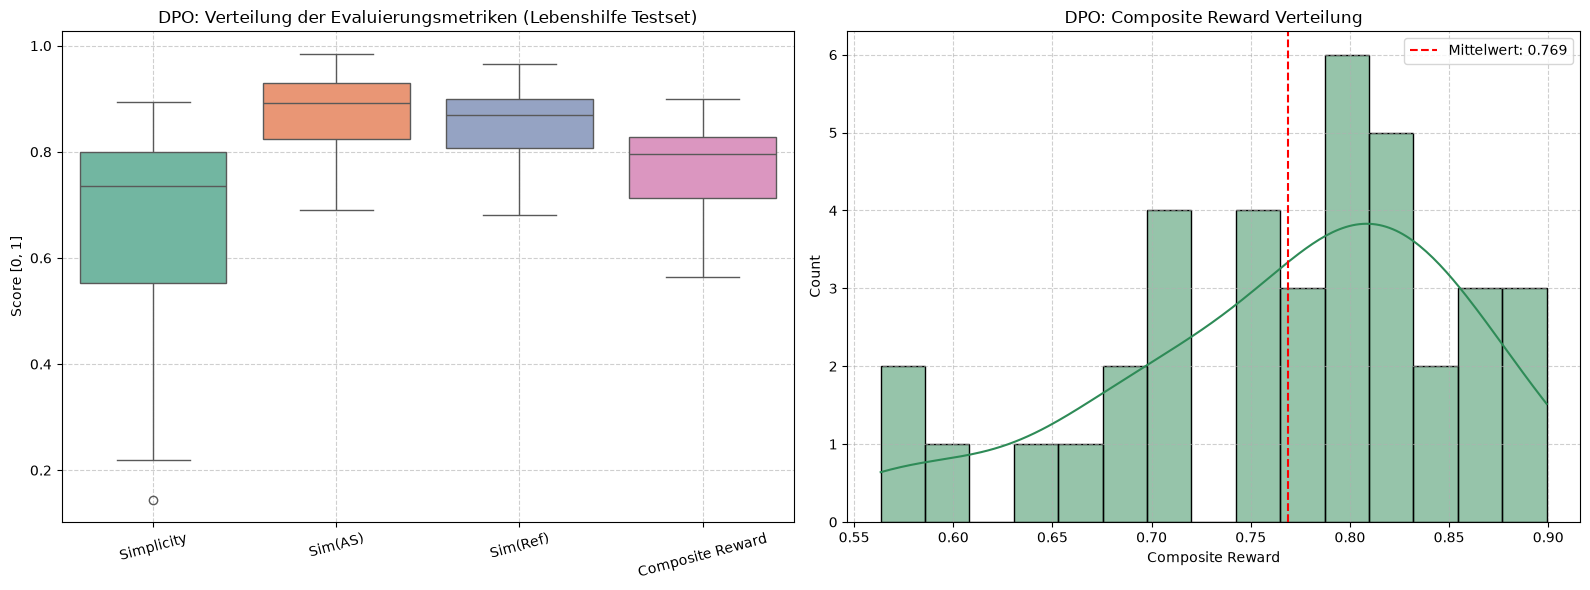

In [9]:
os.makedirs("results/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot der Metriken
sns.boxplot(data=dpo_eval_df[metrics_cols], ax=axes[0], palette="Set2")
axes[0].set_title("DPO: Verteilung der Evaluierungsmetriken (Lebenshilfe Testset)", fontsize=12)
axes[0].set_ylabel("Score [0, 1]")
axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. KDE / Histogramm des Composite Rewards
sns.histplot(dpo_eval_df["composite_reward"], kde=True, ax=axes[1], color="seagreen", bins=15)
axes[1].axvline(dpo_eval_df["composite_reward"].mean(), color="red", linestyle="--", label=f"Mittelwert: {dpo_eval_df['composite_reward'].mean():.3f}")
axes[1].set_title("DPO: Composite Reward Verteilung", fontsize=12)
axes[1].set_xlabel("Composite Reward")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out_path = "results/plots/dpo_lebenshilfe_metrics.png"
plt.savefig(plot_out_path, dpi=300)
print(f"Plot gespeichert unter: {plot_out_path}")
plt.show()

## 8. Interaktiver Übersetzungstest

In [10]:
def translate_dpo_text(text, prompt_prefix=PROMPT_PREFIX):
    prompt_input = (prompt_prefix + text) if prompt_prefix else text
    inputs = tokenizer(prompt_input, return_tensors="pt", max_length=MAX_SOURCE_LEN, truncation=True).to(DEVICE)
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    with torch.no_grad():
        generated_ids = dpo_model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_bos_token_id=forced_bos_id
        )
    translation = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
    
    tot_reward, r_style, r_sem_norm = reward_evaluator.compute_reward([text], [translation])
    
    print("[Eingabe (AS)]:")
    print(text)
    print("")
    print("[DPO-Übersetzung (LS)]:")
    print(translation)
    print("")
    print(f"[Scores]: Simplicity={r_style[0]:.3f} | SBERT(AS)={r_sem_norm[0]:.3f} | Composite Reward={tot_reward[0]:.3f}")
    return translation

# Beispiel testen:
test_input = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."
translate_dpo_text(test_input);


[Eingabe (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

[DPO-Übersetzung (LS)]:
Was sind Hunde? Hunde sind Haustiere. Sie begleiten die Menschen schon seit Jahrtausenden. Hunde sind das älteste Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

[Scores]: Simplicity=0.424 | SBERT(AS)=0.880 | Composite Reward=0.652
